In [1]:
import numpy as np
import torch
import scipy
import matplotlib.pyplot as plt
import os

In [2]:
class PlaceCells1D(object):

    def __init__(self, options):
        self.Np = options.Np
        self.track_length = options.track_length
        self.sigma = options.place_cell_rf
        self.seed = options.plce_cell_seed
        self.device = options.device
        self.periodic = options.periodic

        # Randomly initialize place cell centers: 1d array of shape [Np].
        np.random.seed(self.seed)
        # self.centers = torch.tensor(np.random.uniform(-self.track_length/2, self.track_length/2, self.Np))
        self.centers = torch.tensor(np.linspace(-self.track_length/2, self.track_length/2, self.Np))
        self.centers = self.centers.to(self.device)

    def get_activation(self, pos):
        '''
        Get the activation of the place cells given the position of the agent

        Inputs:
            pos: (batch_size, seq_len, 1) tensor of the position of the agent

        Outputs:
            activation: (batch_size, seq_len, Np) tensor of the activation of the place cells
        '''

        # Compute distance between position and place cell centers: [batch_size, sequence_length, Np].
        d = torch.abs(pos[:, :, None, :] - self.centers[None, None, :, None]).float().squeeze(-1)
        if self.periodic:
            d = torch.min(d, self.track_length - d)

        if self.sigma is not None:
            # use gaussian activation
            activation = torch.exp(-d**2 / (2 * self.sigma**2))
        else:
            # use one hot encoding
            min_vals, _ = torch.min(d, dim=-1, keepdim=True)
            activation = (d == min_vals).float()

        return activation

    def get_nearest_cell_pos(self, activation, k=3):
        '''
        Decode position using centers of k maximally active place cells.
        
        Args: 
            activation: Place cell activations of shape [batch_size, sequence_length, Np].
            k: Number of maximally active place cells with which to decode position.

        Returns:
            pred_pos: Predicted 2d position with shape [batch_size, sequence_length, 1].
        '''
        # top-k place cells along the last dimension; idx: [batch_size, sequence_length, k]
        _, idxs = torch.topk(activation, k=k)
        # centers[idxs] will slice the centers along the last dimension using the indices in idxs: [batch_size, sequence_length, k]
        pred_pos = self.centers[idxs].mean(-1, keepdim=True)
        return pred_pos

In [3]:
class TrajectoryGenerator1D(object):

    def __init__(self, options, place_cell):
        self.options = options
        self.place_cell = place_cell

    def avoid_wall(self, position):
        '''
        Avoid the wall by reflecting the position when the agent hits the wall

        Inputs:
            position: (batch_size) tensor of the CURRENT position of the agent
            dt: float, time step

        Outputs:
            position: (batch_size) tensor of the position of the agent after reflection
        '''
        track_length = self.place_cell.track_length
        dt = self.options.dt
        # check if the agent hits the wall
        hit_wall = (position.abs() >= track_length / 2)
        # if the agent hits the wall, current position should be border - the amount of overshoot
        sign = torch.sign(position[hit_wall])
        position[hit_wall] = sign * track_length / 2 - (position[hit_wall] - sign * track_length / 2)
        return position

    def generate_trajectory(self, seed=None):
        '''
        Generate a batch of trajectories

        Inputs:
            batch_size: int, number of trajectories to generate
            seq_len: int, length of each trajectory

        Outputs:
            traj: (batch_size, seq_len) tensor of the generated trajectories
        '''
        if seed:
            torch.manual_seed(seed)
        track_length = self.place_cell.track_length
        batch_size = self.options.batch_size
        seq_len = self.options.seq_len
        dt = self.options.dt
        # initialize position; add 2 to seq_len to account for initial and final positions
        # we will discard the final position later
        position = torch.zeros(batch_size, seq_len+2)

        # random initial position; between -track_length/2 and track_length/2
        position[:, 0] = torch.rand(batch_size) * track_length - track_length / 2

        # IMPORTANT: For nonperiodic boundary, using a positive velocity will like to result in bouncing back and forth near a wall
        velocity = torch.rand((batch_size, seq_len+1)) * 2 - 1

        for t in range(seq_len + 1):
            v = velocity[:, t]
            position[:, t+1] = position[:, t] + v * dt
            # for non-periodic boundary, check if the updated position hits the wall, if so reflect the position
            if not self.options.periodic:
                position[:, t+1] = self.avoid_wall(position[:, t+1])
        
        # for periodic boundary, wrap the position
        if self.options.periodic:
            position = (position + track_length / 2) % track_length - track_length / 2

        traj = {}
        traj['position'] = position[:, 1:-1].to(self.options.device) # discard initial and final positions, [batch_size, seq_len]
        traj['velocity'] = velocity[:, 1:].to(self.options.device) # discard initial velocity, [batch_size, seq_len]
        traj['init_position'] = position[:, 0].unsqueeze(-1).to(self.options.device)# [batch_size, 1]

        return traj

    def get_batch_data(self, seed=None):
        '''
        Generate a batch of trajectories and their corresponding place cell activations

        Outputs:
            input: (velocity, init_activation), where velocity is a (batch_size, seq_len, 1) tensor of the velocity of the agent
                and init_activation is a (batch_size, 1) tensor of the activation of the place cells at the initial position
            activation: (batch_size, seq_len, Np) tensor of the activation of the place cells
            position: (batch_size, seq_len, 1) tensor of the generated 1d trajectories
        '''
        traj = self.generate_trajectory(seed)
        # unsqueeze the position to match the shape of the place cell activations
        activation = self.place_cell.get_activation(traj['position'].unsqueeze(-1))
        init_activation = self.place_cell.get_activation(traj['init_position'].unsqueeze(-1))
        # unsqueeze the velocity to have 1 in the last dimension
        input = (traj['velocity'].unsqueeze(-1), init_activation.squeeze())
        return (input, activation, traj['position'].unsqueeze(-1))

    def get_generator(self, seed=None):
        while True:
            yield self.get_batch_data(seed)

    def get_test_batch(self, seed=None):
        return self.get_batch_data(seed)


## Explorations

In [13]:
# generate a batch for visualization
class Options():
    Np = 20
    track_length = 1
    place_cell_rf = 0.05
    plce_cell_seed = 0
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    periodic = False
    batch_size = 5
    seq_len = 20
    dt = 0.1 # larger dt results in discontinuous place cell activations, which isn't bad
options = Options()

place_cell = PlaceCells1D(options)
generator = TrajectoryGenerator1D(options, place_cell)

input, activation, pos = generator.get_test_batch()
velocity, init_activation = input
print(velocity.shape, init_activation.shape, activation.shape, pos.shape)


torch.Size([5, 20, 1]) torch.Size([5, 20]) torch.Size([5, 20, 20]) torch.Size([5, 20, 1])


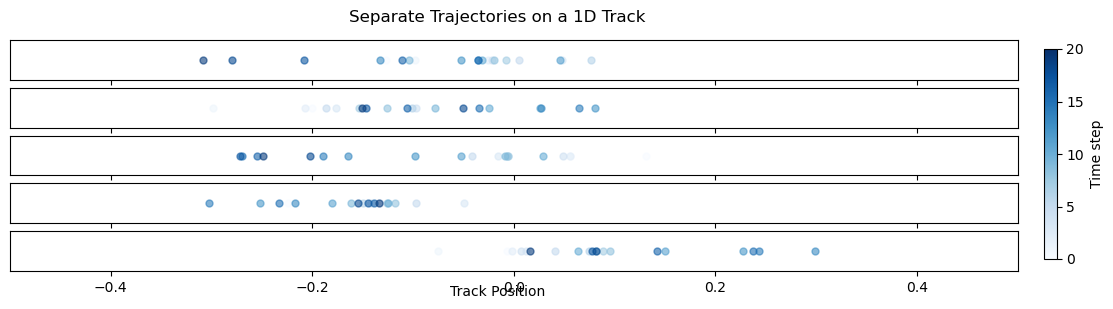

In [14]:
trajectories = pos[:5].cpu().numpy()
l = options.track_length / 2
fig, axes = plt.subplots(5, 1, figsize=(13, 3), sharex=True)

# Colormap for the time points in each trajectory
time_cmap = plt.cm.Blues

# Normalize the time points for the colormap
norm = plt.Normalize(0, trajectories.shape[1])

# Plot each trajectory in its own subplot
for i, (ax, traj) in enumerate(zip(axes, trajectories)):
    for j, point in enumerate(traj):
        ax.plot(point, 0, 'o', color=time_cmap(norm(j)), markersize=5, alpha=0.6)
    
    ax.set_xlim(-l, l)
    ax.set_ylim(-0.1, 0.1)
    ax.get_yaxis().set_visible(False)  # Hide the y-axis
    # ax.get_xaxis().set_visible(False)  # Hide the x-axis

fig.text(0.5, 0.04, 'Track Position', ha='center', va='center')
fig.suptitle('Separate Trajectories on a 1D Track')

# add a colorbar for the time points
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap=time_cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Time step')

plt.show()

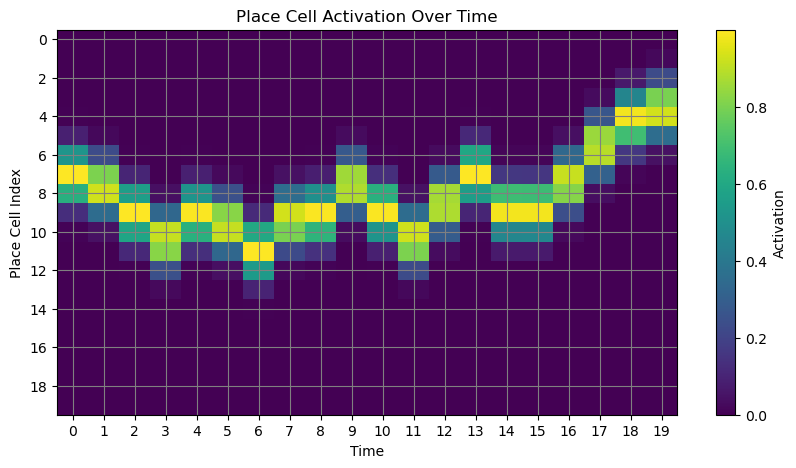

In [15]:
# visualize the place cell activations, sorted by the center of the place cell
sort_idx = np.argsort(place_cell.centers.cpu().numpy())
sample_activation = activation[0].cpu().numpy()
sample_activation = sample_activation[:, sort_idx]
plt.figure(figsize=(10, 5))
plt.imshow(sample_activation.T, aspect='auto', cmap='viridis')
plt.yticks(np.arange(0, options.Np, options.Np/10))
plt.xticks(np.arange(0, options.seq_len, 1))
plt.colorbar(label='Activation')
plt.xlabel('Time')
plt.ylabel('Place Cell Index') 
plt.title('Place Cell Activation Over Time')
ax = plt.gca()
ax.grid(color='gray')
plt.show()

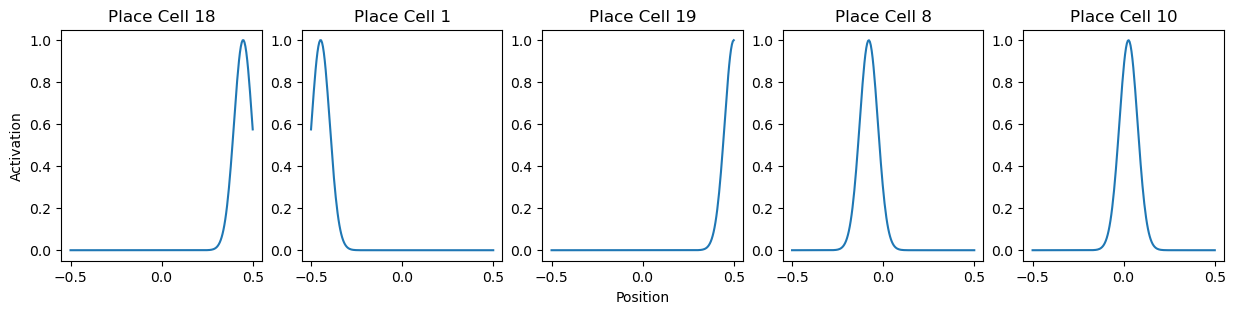

In [16]:
# visualize the place fields by plotting them on a grid
# uniformly sample the position
res = 200
pos = np.linspace(-options.track_length/2, options.track_length/2, res)
pos = torch.tensor(pos).unsqueeze(0).unsqueeze(-1).to(options.device)
activation = place_cell.get_activation(pos).cpu().numpy()
activation = activation.squeeze(0)

# visualize a few place fields
n = 5
fig, axes = plt.subplots(1, n, figsize=(15, 3))
rdn_idx = np.random.choice(options.Np, n, replace=False)
for i, idx in enumerate(rdn_idx):
    axes[i].plot(np.linspace(-options.track_length/2, options.track_length/2, res), activation[:, idx])
    axes[i].set_title(f'Place Cell {idx}')
    # set overall x and y labels
    if i == 0:
        axes[i].set_ylabel('Activation')
    if i == n // 2:
        axes[i].set_xlabel('Position')
plt.show()

When Np is small, because of the randomness and sparsity of place cell centers, many positions will excite one single place cell.

## Training RNN

In [4]:
def generate_traj_data(options):
    # generate a batch of full size data and save it to a .npz file
    bsz = options.batch_size
    options.batch_size = bsz * options.n_steps
    place_cells = PlaceCells1D(options)
    trajectory_generator = TrajectoryGenerator1D(options, place_cells)

    gen = trajectory_generator.get_generator()
    inputs, pc_outputs, pos = next(gen)

    v = inputs[0]
    init_actv = inputs[1]

    # create a path called 'data' if it doesn't exist
    if not os.path.exists('data'):
        os.makedirs('data')

    np.savez(f'data/trajectory1d_{options.batch_size}_{options.seq_len}_{options.Np}.npz',
        v=v.cpu().numpy(),
        init_actv=init_actv.cpu().numpy(),
        pc_outputs=pc_outputs.cpu().numpy(),
        pos=pos.cpu().numpy(),
        centers=place_cells.centers.cpu().numpy()
    )

    print(f'Generated {options.batch_size} trajectories. Sizes: velocity: {v.shape}, \
        initial activation: {init_actv.shape}, \
        place cell outputs: {pc_outputs.shape}, \
        position: {pos.shape}'
    )

    options.batch_size = bsz

class Trjectory(torch.utils.data.Dataset):
    def __init__(self, npz_path):
        # Load the .npz file
        self.data = np.load(npz_path, mmap_mode='r')

        # Access the individual arrays. The keys ('v', 'init_activation', etc.)
        # need to match the names used when the .npz file was created.
        self.v = self.data['v']  # Shape: [batch_size, sequence_length, 1]
        self.init_actv = self.data['init_actv']  # Shape: [batch_size, Np]
        self.pc_outputs = self.data['pc_outputs']  # Shape: [batch_size, sequence_length, Np]
        self.pos = self.data['pos']  # Shape: [batch_size, sequence_length, 1]

    def __len__(self):
        # Assuming all arrays have the same number of samples (50000)
        return self.v.shape[0]

    def __getitem__(self, idx):
        # Fetch the elements for the given index
        v_sample = self.v[idx]  # Shape: [sequence_length, 1]
        init_activation_sample = self.init_actv[idx]  # Shape: [Np]
        pc_outputs_sample = self.pc_outputs[idx]  # Shape: [sequence_length, Np]
        pos_sample = self.pos[idx]  # Shape: [sequence_length, 1]

        # Inputs is a tuple of (v, init_activation)
        inputs = (v_sample, init_activation_sample)

        # Return a tuple of inputs, pc_output, and pos
        return inputs, pc_outputs_sample, pos_sample

def get_traj_loader(path, options):
    # Create a Trajectory dataset
    dataset = Trjectory(path)

    # Create a DataLoader from the Trajectory dataset
    loader = torch.utils.data.DataLoader(dataset, batch_size=options.batch_size, shuffle=True)

    return loader

In [5]:
class RNN(torch.nn.Module):
    def __init__(self, options, place_cells):
        super(RNN, self).__init__()
        self.Ng = options.Ng
        self.Np = options.Np
        self.sequence_length = options.seq_len
        self.weight_decay = options.weight_decay
        self.place_cells = place_cells

        # Input weights
        self.encoder = torch.nn.Linear(self.Np, self.Ng, bias=False)
        self.RNN = torch.nn.RNN(input_size=1,
                                hidden_size=self.Ng,
                                nonlinearity=options.activation,
                                bias=False,
                                batch_first=True)
        # Linear read-out weights
        self.decoder = torch.nn.Linear(self.Ng, self.Np, bias=True)
        
        self.softmax = torch.nn.Softmax(dim=-1)
        self.loss = torch.nn.CrossEntropyLoss()

    def g(self, inputs):
        '''
        Compute grid cell activations.
        Args:
            inputs: Batch of 1d velocity inputs with shape [batch_size, sequence_length].

        Returns: 
            g: Batch of grid cell activations with shape [batch_size, sequence_length, Ng].
        '''
        v, p0 = inputs
        init_state = self.encoder(p0)[None] # [1, batch_size, Np] as per RNN input format
        g,_ = self.RNN(v, init_state) # [batch_size, sequence_length, Ng]
        return g
    

    def predict(self, inputs):
        '''
        Predict place cell code.
        Args:
            inputs: Batch of 1d velocity inputs with shape [batch_size, sequence_length].

        Returns: 
            place_preds: Predicted place cell activations with shape 
                [batch_size, sequence_length, Np].
        '''
        place_preds = self.decoder(self.g(inputs))
        
        return place_preds


    def compute_loss(self, inputs, pc_outputs, pos):
        '''
        Compute avg. loss and decoding error.
        Args:
            inputs: Batch of 2d velocity inputs with shape [batch_size, sequence_length, 1].
            pc_outputs: Ground truth place cell activations with shape 
                [batch_size, sequence_length, Np].
            pos: Ground truth 2d position with shape [batch_size, sequence_length, 1].

        Returns:
            loss: Avg. loss for this training batch.
            err: Avg. decoded position error in cm.
        '''
        y = pc_outputs
        # preds = self.softmax(self.predict(inputs))
        # loss = -(y*torch.log(preds + )).sum(-1).mean()
        y = y.reshape(-1, self.Np)
        # torch celoss works better with class indices
        # since we are using one-hot place fields, we can use argmax to get the class/cell indices
        loss = self.loss(self.predict(inputs).reshape(-1, self.Np), y.argmax(-1))

        # Weight regularization 
        loss += self.weight_decay * (self.RNN.weight_hh_l0**2).sum()

        # Compute decoding error
        preds = self.softmax(self.predict(inputs))
        pred_pos = self.place_cells.get_nearest_cell_pos(preds)
        err = torch.sqrt(((pos - pred_pos)**2).sum(-1)).mean()

        return loss, err

In [6]:
class Trainer(object):
    def __init__(self, options, model, trajectory_generator, restore=True):
        self.options = options
        self.model = model
        self.trajectory_generator = trajectory_generator
        lr = self.options.learning_rate
        self.optimizer = torch.optim.Adam(self.model.parameters(), 
            lr=lr,
            # weight_decay=options.weight_decay,
        )
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, 
            step_size=options.decay_step_size, 
            gamma=options.decay_rate,
        )

        self.loss = []
        self.err = []

    def train_step(self, inputs, pc_outputs, pos):
        ''' 
        Train on one batch of trajectories.

        Args:
            inputs: Batch of 1d velocity inputs with shape [batch_size, sequence_length].
            pc_outputs: Ground truth place cell activations with shape 
                [batch_size, sequence_length, Np].
            pos: Ground truth 2d position with shape [batch_size, sequence_length].

        Returns:
            loss: Avg. loss for this training batch.
            err: Avg. decoded position error in cm.
        '''
        self.model.zero_grad()
        loss, err = self.model.compute_loss(inputs, pc_outputs, pos)

        loss.backward()
        self.optimizer.step()

        return loss.item(), err.item()

    def train(self, n_epochs: int = 1000, n_steps=10, save=True, preloaded_data=None):
        ''' 
        Train model on simulated trajectories.

        We can either use pre-generated data, or generate new data for each epoch.
        However, generating new data for each epoch will result in a dynamic dataset i.e., 
            the data will be different for each epoch.

        Args:
            n_steps: Number of training steps
            save: If true, save a checkpoint after each epoch.
        '''

        if not preloaded_data:
            # Construct generator
            gen = self.trajectory_generator.get_generator()
        else:
            path = f'data/trajectory1d_{options.batch_size*options.n_steps}_{options.seq_len}_{options.Np}.npz'
            # check if the file exists
            if os.path.exists(path):
                print('Loading pre-generated data')
            else:
                print('Generating new data')
                generate_traj_data(options)

            dataloader = get_traj_loader(path, options)

        # tbar = tqdm(range(n_steps), leave=False)
        for epoch_idx in range(n_epochs):
            epoch_loss = 0
            epoch_err = 0
            if preloaded_data:
                for inputs, pc_outputs, pos in dataloader:
                    inputs = (inputs[0].to(options.device), inputs[1].to(options.device))
                    pc_outputs, pos = pc_outputs.to(options.device), pos.to(options.device)
                    loss, err = self.train_step(inputs, pc_outputs, pos)
                    epoch_loss += loss
                    epoch_err += err
            else:
                for step_idx in range(n_steps):
                    inputs, pc_outputs, pos = next(gen)
                    inputs = (inputs[0].to(options.device), inputs[1].to(options.device))
                    pc_outputs, pos = pc_outputs.to(options.device), pos.to(options.device)
                    loss, err = self.train_step(inputs, pc_outputs, pos)
                    epoch_loss += loss
                    epoch_err += err
                    
            self.loss.append(epoch_loss / n_steps)
            self.err.append(epoch_err / n_steps)

            print('Epoch: {}/{}. Loss: {}. Err: {}cm'.format(
                    epoch_idx, n_epochs,
                    np.round(epoch_loss / n_steps, 6), 
                    np.round(100 * (epoch_err / n_steps), 2)))
            # print weight norm
            rnn = self.model.RNN
            print(f'RNN weight norm: {rnn.weight_hh_l0.norm()}')

            # Update learning rate
            self.scheduler.step()

        # save model
        save_dir = 'models/1d_models/'
        if save:
            if not os.path.exists(save_dir):
                os.makedirs(save_dir)
            torch.save(self.model.state_dict(), save_dir + '1d_model.pt')


In [30]:
class Options():
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    Np = 100
    Ng = 20
    track_length = 1.0
    # 0.05 is a good value for sigma, 
    # or None for one-hot encoding
    place_cell_rf = 0.05
    plce_cell_seed = 0
    periodic = False
    seq_len = 20
    dt = 0.01
    batch_size = 500
    n_epochs = 300
    n_steps = 100
    learning_rate = 1e-3
    weight_decay = 1e-3
    activation = 'relu'
    decay_step_size = 10
    decay_rate = 0.9
options = Options()

place_cell = PlaceCells1D(options)
generator = TrajectoryGenerator1D(options, place_cell)

model = RNN(options, place_cell).to(options.device)
trainer = Trainer(options, model, generator, restore=False)

In [31]:
trainer.train(n_epochs=options.n_epochs, n_steps=options.n_steps, save=True, preloaded_data=False)

Epoch: 0/300. Loss: 4.575208. Err: 26.64cm
RNN weight norm: 2.5865478515625
Epoch: 1/300. Loss: 3.692922. Err: 12.73cm
RNN weight norm: 3.0248160362243652
Epoch: 2/300. Loss: 3.090843. Err: 4.37cm
RNN weight norm: 3.131518840789795
Epoch: 3/300. Loss: 2.692714. Err: 3.12cm
RNN weight norm: 3.1856753826141357
Epoch: 4/300. Loss: 2.382427. Err: 2.26cm
RNN weight norm: 3.2017271518707275
Epoch: 5/300. Loss: 2.221949. Err: 1.84cm
RNN weight norm: 3.215364933013916
Epoch: 6/300. Loss: 2.131087. Err: 1.76cm
RNN weight norm: 3.221721649169922
Epoch: 7/300. Loss: 2.050812. Err: 1.65cm
RNN weight norm: 3.235168933868408
Epoch: 8/300. Loss: 1.995625. Err: 1.58cm
RNN weight norm: 3.243131637573242
Epoch: 9/300. Loss: 1.943048. Err: 1.52cm
RNN weight norm: 3.2542307376861572
Epoch: 10/300. Loss: 1.891915. Err: 1.47cm
RNN weight norm: 3.265228748321533
Epoch: 11/300. Loss: 1.855321. Err: 1.43cm
RNN weight norm: 3.274620294570923
Epoch: 12/300. Loss: 1.82615. Err: 1.44cm
RNN weight norm: 3.281979799

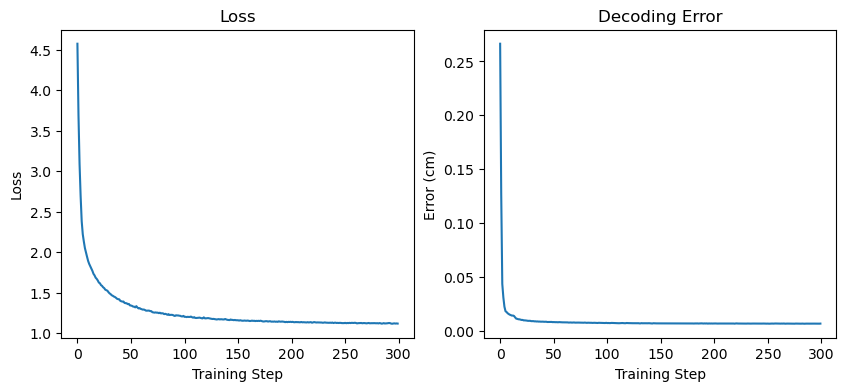

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(trainer.loss)
axes[0].set_title('Loss')
axes[0].set_xlabel('Training Step')
axes[0].set_ylabel('Loss')
axes[1].plot(trainer.err)
axes[1].set_title('Decoding Error')
axes[1].set_xlabel('Training Step')
axes[1].set_ylabel('Error (cm)')
plt.show()

torch.Size([5, 20, 1])


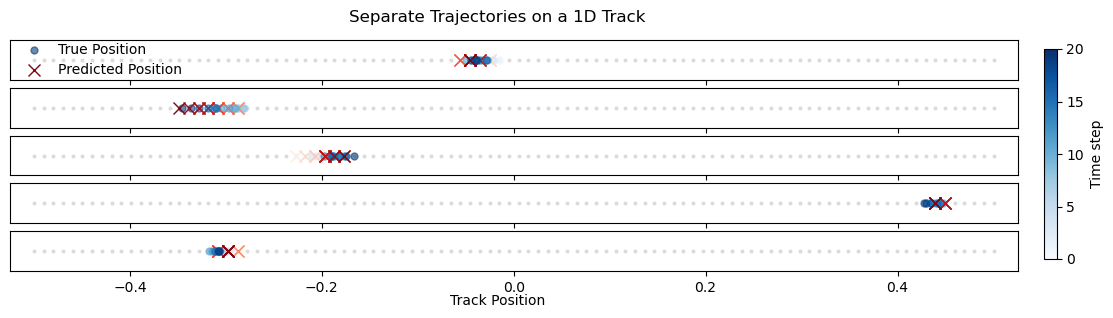

In [33]:
# check if the model generalizes well
inputs, pc_outputs, pos = generator.get_test_batch()
pos = pos.cpu()[:5]
pred_pos = place_cell.get_nearest_cell_pos(model.predict(inputs)).cpu()[:5]
print(pred_pos.shape)
centers = place_cell.centers.cpu()
l = options.track_length/2

fig, axes = plt.subplots(5, 1, figsize=(13, 3), sharex=True)

# Colormap for the time points in each trajectory
time_cmap = plt.cm.Blues
test_cmap = plt.cm.Reds

# Normalize the time points for the colormap
norm = plt.Normalize(0, pos.shape[1])

# Plot each trajectory in its own subplot
for i, (ax, traj) in enumerate(zip(axes, pos)):
    ax.plot(centers, torch.zeros_like(centers), 'o', color='gray', markersize=2, alpha=0.2)
    for j, point in enumerate(traj):
        ax.plot(traj[j], 0, 'o', color=time_cmap(norm(j)), markersize=5, alpha=0.6)
        ax.plot(pred_pos[i, j], 0, 'x', color=test_cmap(norm(j)), markersize=8)
    
    if i == 0:
        # add a legend
        ax.plot(-l, 0.05, 'o', color=time_cmap(norm(pos.shape[1]-1)), markersize=5, alpha=0.6)
        ax.text(-l+l/20, 0.05, 'True Position', va='center', ha='left')
        ax.plot(-l, -0.05, 'x', color=test_cmap(norm(pos.shape[1]-1)),markersize=8)
        ax.text(-l+l/20, -0.05, 'Predicted Position', va='center', ha='left')

    
    ax.set_xlim(-l-l/20, l+l/20)
    ax.set_ylim(-0.1, 0.1)
    ax.get_yaxis().set_visible(False)  # Hide the y-axis
    # ax.get_xaxis().set_visible(False)  # Hide the x-axis

fig.text(0.5, 0.01, 'Track Position', ha='center', va='center')
fig.suptitle('Separate Trajectories on a 1D Track')

# add a colorbar for the time points
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap=time_cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Time step')

plt.show()

In [34]:
# get grid cell rate maps
def compute_ratemaps(
        model, 
        trajectory_generator,  
        options, 
        res=20, 
        n_avg=None, 
        Ng=512, 
        idxs=None,
    ):
    '''Compute spatial firing fields'''

    g = np.zeros([n_avg, options.batch_size * options.seq_len, Ng])
    pos = np.zeros([n_avg, options.batch_size * options.seq_len, 1])

    activations = np.zeros([Ng, res]) 
    counts  = np.zeros(res)

    for index in range(n_avg):
        # pos_batch: [batch_size, seq_len, 2]
        inputs, _, pos_batch = trajectory_generator.get_test_batch()

        g_batch = model.g(inputs).detach().cpu().numpy().reshape(-1, Ng) # [seq_len*batch_size, Ng]
        
        pos_batch = pos_batch.cpu().numpy().reshape(-1, 1) # [seq_len*batch_size, 1]

        # g_batch records the activations of all grid cells across all points in all trajectories in this batch
        g_batch = g_batch.reshape(-1, Ng) # [seq_len*batch_size, Ng]
        
        g[index] = g_batch
        pos[index] = pos_batch

        # Convert position (-1, 1) to indices (0, res)
        pos_batch = (pos_batch + options.track_length/2) / (options.track_length) * res

        for i in range(options.batch_size*options.seq_len):
            x = pos_batch[i, 0]
            if x >=0 and x < res:
                counts[int(x)] += 1
                activations[:, int(x)] += g_batch[i, :]

    # make it a density map
    for k in range(res):
        if counts[k] > 0:
            activations[:, k] /= counts[k]
                
    g = g.reshape([-1, Ng])
    pos = pos.reshape([-1, 1])
    rate_map = activations.reshape(Ng, -1)

    return rate_map

rate_map = compute_ratemaps(model, generator, options, n_avg=200, res=200, Ng=options.Ng)


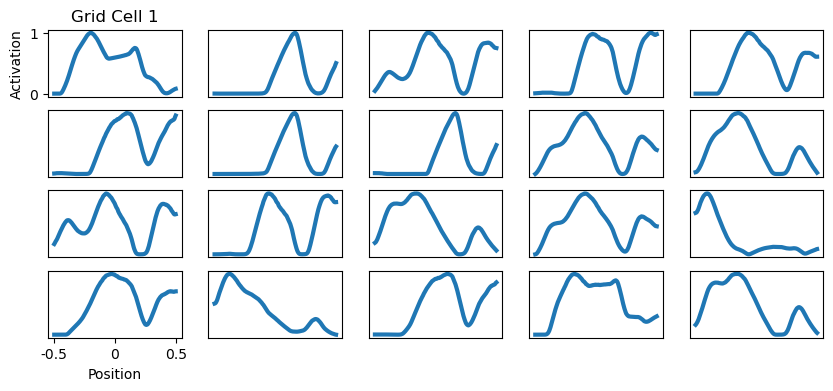

In [35]:
# visualize the rate maps
n_col = 4
fig, ax = plt.subplots(n_col, options.Ng//n_col, figsize=(2*options.Ng//n_col, n_col))
for i, ax in enumerate(ax.flatten()):
    r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
    ax.plot(np.linspace(-options.track_length/2, options.track_length/2, 200), r, lw=3)
    # set overall x and y labels
    if i == 0:
        ax.set_ylabel('Activation')
        ax.set_title(f'Grid Cell {i+1}')
    else:
        ax.get_yaxis().set_visible(False)
        
    if i == options.Ng // n_col * (n_col - 1):
        ax.set_xlabel('Position')
    else:
        ax.get_xaxis().set_visible(False)

    ax.set_xticks([-options.track_length/2, 0, options.track_length/2])
    ax.set_xticklabels([-options.track_length/2, 0, options.track_length/2])
plt.show()